# ARC-AGI-3 Solver — Qwen3.8-27B-FP8 — 25-Game P1 Public Eval

Public/offline evaluation is overridden to the same 25 public games × 1 pass shape. Competition reruns still use the live private game list from the Kaggle gateway.


In [1]:
import contextlib
import json
import os
import pickle
import subprocess
import sys
import time
from datetime import datetime, timedelta
from pathlib import Path
from typing import TextIO
from urllib.request import urlopen


def _env_bool(name: str, default: bool = False) -> bool:
    raw = os.getenv(name, "").strip().lower()
    if not raw:
        return default
    return raw in {"1", "true", "yes", "y", "on"}


NOTEBOOK_START_EPOCH = time.time()
RUN_AS_SUBMISSION = False
RUN_AS_SUBMISSION = RUN_AS_SUBMISSION or _env_bool("KAGGLE_IS_COMPETITION_RERUN", False)
ENABLE_GPU = True

os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if RUN_AS_SUBMISSION else "0"
os.environ.setdefault("MPLBACKEND", "Agg")

if ENABLE_GPU:
    cuda_library_path = "/usr/local/nvidia/lib64"
    existing = [entry for entry in os.environ.get("LIBRARY_PATH", "").split(os.pathsep) if entry]
    os.environ["LIBRARY_PATH"] = os.pathsep.join(
        [cuda_library_path, *[entry for entry in existing if entry != cuda_library_path]]
    )

print(f"TAAF RUN_AS_SUBMISSION={RUN_AS_SUBMISSION}")
if ENABLE_GPU:
    print(f"taaf.kaggle: LIBRARY_PATH={os.environ['LIBRARY_PATH']}")

TAAF RUN_AS_SUBMISSION=False
taaf.kaggle: LIBRARY_PATH=/usr/local/nvidia/lib64:/usr/local/cuda/lib64/stubs


In [2]:
wheelhouse = Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels")
if wheelhouse.exists():
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-index",
            "--no-warn-conflicts",
            "--disable-pip-version-check",
            "--find-links",
            str(wheelhouse),
            "arc-agi",
        ]
    )
elif os.getenv("TAAF_KAGGLE_BUNDLE_DIR"):
    print(f"Competition wheelhouse not found at {wheelhouse}; assuming local debug dependencies are installed.")
else:
    raise RuntimeError(f"Competition wheelhouse not found at {wheelhouse}.")

Looking in links: /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/arc_agi-0.9.8-py3-none-any.whl
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/arcengine-0.9.3-py3-none-any.whl (from arc-agi)
Processing /kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels/pillow-12.2.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (from arc-agi)
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


In [3]:
# Qwen3.8 / Kaggle input configuration
DATASET_SOURCES: list[str] = [
    "jakobbrggen/taaf-kaggle-source-anim-20260807-anim",
    "driessmit1/arc3-vllm-h100-wheelhouse-v3",
]
KERNEL_SOURCES: list[str] = []

# New private Kaggle Model (Version 1).
QWEN_MODEL_OWNER = "foysalemonshanto"
QWEN_MODEL_SLUG = "qwen3-8-27b-fp8-repacked-v1"
QWEN_MODEL_REF = f"{QWEN_MODEL_OWNER}/{QWEN_MODEL_SLUG}"
QWEN_MODEL_VARIATION = "hf-fp8"
QWEN_MODEL_VERSION = "1"
QWEN_SERVED_MODEL_NAME = "Qwen/Qwen3.8-27B-FP8"
QWEN_MODEL_PATH = Path(
    f"/kaggle/input/models/{QWEN_MODEL_OWNER}/{QWEN_MODEL_SLUG}/"
    f"pytorch/{QWEN_MODEL_VARIATION}/{QWEN_MODEL_VERSION}"
)

DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
WORKING_DIR = Path(os.getenv("TAAF_KAGGLE_WORKING_DIR", "/kaggle/working")).resolve()
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"
SOFT_DEADLINE_BUFFER_S = 600.0
WORKING_DIR.mkdir(parents=True, exist_ok=True)

# Keep the whole run offline. vLLM/Transformers must use the mounted files only.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"


def _split_ref(ref: str) -> tuple[str, str]:
    owner, slug = ref.split("/", 1)
    return owner, slug


def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = _split_ref(ref)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = _split_ref(ref)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((candidate for candidate in candidates if candidate.exists()), None)


def _find_taaf_bundle() -> Path:
    explicit = os.getenv("TAAF_KAGGLE_BUNDLE_DIR", "").strip()
    if explicit:
        path = Path(explicit)
        if (path / DATASET_BUNDLE_MARKER).is_file():
            return path

    # Prefer the attached bundle whose marker actually exists.
    for root in [Path("/kaggle/input/datasets"), Path("/kaggle/input"), Path.cwd()]:
        if root.exists():
            for marker in root.rglob(DATASET_BUNDLE_MARKER):
                return marker.parent

    raise RuntimeError("Could not find TAAF Kaggle source bundle dataset.")


def _load_setup_env() -> dict[str, str]:
    if not SETUP_ENV_PATH.is_file():
        return {}
    data = json.loads(SETUP_ENV_PATH.read_text(encoding="utf-8"))
    if not isinstance(data, dict):
        raise RuntimeError(f"{SETUP_ENV_PATH} must contain a JSON object.")
    return {str(key): str(value) for key, value in data.items()}


def _write_setup_env_updates(updates: dict[str, str]) -> None:
    data = _load_setup_env()
    data.update(updates)
    SETUP_ENV_PATH.write_text(
        json.dumps(data, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )


BUNDLE_DIR = _find_taaf_bundle()
print(f"TAAF source bundle: {BUNDLE_DIR}")

# Verify the Qwen3.8 Kaggle Model before any expensive setup work starts.
if not QWEN_MODEL_PATH.is_dir():
    raise FileNotFoundError(
        "Qwen3.8 Kaggle Model is not attached.\n"
        f"Expected path:\n{QWEN_MODEL_PATH}\n\n"
        "Attach: Qwen3.8 27B FP8 Repacked → PyTorch → hf-fp8 → Version 1"
    )

_required_qwen_files = [
    "config.json",
    "model.safetensors.index.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "outside.safetensors",
    "mtp.safetensors",
    "chat_template.jinja",
]
_missing_qwen_files = [
    name for name in _required_qwen_files if not (QWEN_MODEL_PATH / name).is_file()
]
if _missing_qwen_files:
    raise FileNotFoundError(
        "Qwen3.8 mount is incomplete; missing: " + ", ".join(_missing_qwen_files)
    )

_qwen_layer_shards = sorted(QWEN_MODEL_PATH.glob("model-layers-*.safetensors"))
_qwen_safetensors = sorted(QWEN_MODEL_PATH.glob("*.safetensors"))
if len(_qwen_layer_shards) != 16 or len(_qwen_safetensors) != 18:
    raise RuntimeError(
        "Unexpected Qwen3.8 checkpoint layout: "
        f"{len(_qwen_layer_shards)} layer shards, "
        f"{len(_qwen_safetensors)} safetensors files."
    )

# Tell setup commands and solver code where Kaggle mounted every attached input.
kaggle_input_paths: dict[str, str] = {}
for index, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if index == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])

for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# The bundled setup resolver asks for owner/slug. Give it a model ref that maps
# directly to the full Kaggle Model version directory.
kaggle_input_paths[QWEN_MODEL_REF] = str(QWEN_MODEL_PATH)

setup_env = {
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
    "TAAF_QWEN_MODEL_REF": QWEN_MODEL_REF,
    "TAAF_QWEN_MODEL_PATH": str(QWEN_MODEL_PATH),
    "TAAF_QWEN_SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    "HF_HUB_OFFLINE": "1",
    "TRANSFORMERS_OFFLINE": "1",
}
os.environ.update(setup_env)
_write_setup_env_updates(setup_env)

print("\n✅ Qwen3.8 input configuration ready")
print(f"Model ref:       {QWEN_MODEL_REF}")
print(f"Physical path:   {QWEN_MODEL_PATH}")
print(f"Served model:    {QWEN_SERVED_MODEL_NAME}")
print(f"Safetensors:     {len(_qwen_safetensors)}")
print(f"Layer shards:    {len(_qwen_layer_shards)}")
print(f"TAAF input map:  {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")


TAAF source bundle: /kaggle/input/datasets/jakobbrggen/taaf-kaggle-source-anim-20260807-anim

✅ Qwen3.8 input configuration ready
Model ref:       foysalemonshanto/qwen3-8-27b-fp8-repacked-v1
Physical path:   /kaggle/input/models/foysalemonshanto/qwen3-8-27b-fp8-repacked-v1/pytorch/hf-fp8/1
Served model:    Qwen/Qwen3.8-27B-FP8
Safetensors:     18
Layer shards:    16
TAAF input map:  {"driessmit1/arc3-vllm-h100-wheelhouse-v3": "/kaggle/input/datasets/driessmit1/arc3-vllm-h100-wheelhouse-v3", "foysalemonshanto/qwen3-8-27b-fp8-repacked-v1": "/kaggle/input/models/foysalemonshanto/qwen3-8-27b-fp8-repacked-v1/pytorch/hf-fp8/1", "jakobbrggen/taaf-kaggle-source-anim-20260807-anim": "/kaggle/input/datasets/jakobbrggen/taaf-kaggle-source-anim-20260807-anim"}


In [4]:
# Audit the attached inputs that matter for this run.
print("=== TAAF bundle ===")
print(BUNDLE_DIR)
print("Exists:", BUNDLE_DIR.exists())

print("\n=== vLLM wheelhouse ===")
_vllm_wheelhouse = Path(
    "/kaggle/input/datasets/driessmit1/arc3-vllm-h100-wheelhouse-v3"
)
print(_vllm_wheelhouse)
print("Exists:", _vllm_wheelhouse.exists())

print("\n=== Qwen3.8 Kaggle Model ===")
print(QWEN_MODEL_PATH)
print("Exists:", QWEN_MODEL_PATH.exists())
print("Safetensors:", len(list(QWEN_MODEL_PATH.glob("*.safetensors"))))
print(
    "Repacked layer shards:",
    len(list(QWEN_MODEL_PATH.glob("model-layers-*.safetensors"))),
)


=== TAAF bundle ===
/kaggle/input/datasets/jakobbrggen/taaf-kaggle-source-anim-20260807-anim
Exists: True

=== vLLM wheelhouse ===
/kaggle/input/datasets/driessmit1/arc3-vllm-h100-wheelhouse-v3
Exists: True

=== Qwen3.8 Kaggle Model ===
/kaggle/input/models/foysalemonshanto/qwen3-8-27b-fp8-repacked-v1/pytorch/hf-fp8/1
Exists: True
Safetensors: 18
Repacked layer shards: 16


In [5]:
import re


def _source_path_entries(bundle_dir: Path) -> list[Path]:
    src_root = bundle_dir / "src"
    if not src_root.is_dir():
        return []

    entries: list[Path] = []
    for repo in sorted(src_root.iterdir(), reverse=True):
        if not repo.is_dir():
            continue
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


def _command_env() -> dict[str, str]:
    env = os.environ.copy()
    env["PYTHON"] = sys.executable
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env["HF_HUB_OFFLINE"] = "1"
    env["TRANSFORMERS_OFFLINE"] = "1"
    env.update(_load_setup_env())
    return env


def _replace_python_assignment(
    command: str,
    variable_name: str,
    value: str,
) -> tuple[str, int]:
    """Replace a top-level Python string assignment inside the setup here-doc."""
    pattern = rf"(?m)^{re.escape(variable_name)}\s*=\s*(['\"])[^\r\n]*?\1\s*$"
    replacement = f"{variable_name} = {value!r}"
    return re.subn(pattern, replacement, command, count=1)


def _patch_qwen38_setup_commands(commands: list[str]) -> list[str]:
    """
    Preserve the TAAF deployment setup but replace its model identity with the
    Qwen3.8 Kaggle Model. This avoids copying/forking the large bundled setup
    script and keeps the wheelhouse/GPU/vLLM behavior from the source bundle.
    """
    patched: list[str] = []
    replacement_counts = {
        "MODEL_OWNER": 0,
        "MODEL_SLUG": 0,
        "SERVED_MODEL_NAME": 0,
    }

    replacements = {
        "MODEL_OWNER": QWEN_MODEL_OWNER,
        "MODEL_SLUG": QWEN_MODEL_SLUG,
        "SERVED_MODEL_NAME": QWEN_SERVED_MODEL_NAME,
    }

    for raw_command in commands:
        command = str(raw_command)

        for variable_name, value in replacements.items():
            command, count = _replace_python_assignment(
                command,
                variable_name,
                value,
            )
            replacement_counts[variable_name] += count

        # Make offline behavior explicit in the child process as well.
        if "def vllm_env()" in command:
            command = command.replace(
                "'VLLM_NO_USAGE_STATS': '1',",
                "'VLLM_NO_USAGE_STATS': '1',\n"
                "            'HF_HUB_OFFLINE': '1',\n"
                "            'TRANSFORMERS_OFFLINE': '1',",
                1,
            )

        patched.append(command)

    missing = [
        name for name, count in replacement_counts.items() if count == 0
    ]
    if missing:
        raise RuntimeError(
            "Could not update the bundled TAAF setup for Qwen3.8. "
            "Missing assignment(s): "
            + ", ".join(missing)
            + ". The attached TAAF bundle's setup_commands.json has changed."
        )

    print("taaf.kaggle: Qwen3.8 setup patch =", replacement_counts, flush=True)
    return patched


def _run_shell_commands(filename: str, *, label: str, check: bool) -> None:
    path = BUNDLE_DIR / filename
    if not path.is_file():
        return

    commands = json.loads(path.read_text(encoding="utf-8"))
    if not isinstance(commands, list):
        raise RuntimeError(f"{path} must contain a JSON list of shell commands.")

    if filename == "setup_commands.json":
        commands = _patch_qwen38_setup_commands(commands)

    env = _command_env()
    for command in commands:
        print(f"taaf.kaggle: {label} command: {command}", flush=True)
        result = subprocess.run(
            str(command),
            shell=True,
            check=check,
            cwd=WORKING_DIR,
            env=env,
        )
        if not check and result.returncode != 0:
            print(
                f"taaf.kaggle: {label} command exited with {result.returncode}",
                flush=True,
            )

        # Setup commands may export additional runtime settings.
        env.update(_load_setup_env())
        os.environ.update(env)


# Make bundled TAAF repos importable for this notebook and child Python processes.
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    if str(entry) not in sys.path:
        sys.path.insert(0, str(entry))

if source_entries:
    import sysconfig

    pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
    pth_path.write_text(
        "".join(f"{entry}\n" for entry in source_entries),
        encoding="utf-8",
    )
    print(
        f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)",
        flush=True,
    )

# Run the TAAF deployment setup, patched to use Qwen3.8.
_run_shell_commands("setup_commands.json", label="setup", check=True)

# Setup commands may export PYTHONPATH through TAAF_KAGGLE_SETUP_ENV.
pythonpath_entries = [
    entry for entry in os.environ.get("PYTHONPATH", "").split(os.pathsep) if entry
]
for entry in reversed(pythonpath_entries):
    if entry not in sys.path:
        sys.path.insert(0, entry)

# Fail early if the analyzer is still exposing an old model identity.
_actual_model_id = os.environ.get("INFERENCE_ANALYZER_MODEL", "")
if _actual_model_id != QWEN_SERVED_MODEL_NAME:
    raise RuntimeError(
        "TAAF setup completed, but the analyzer model ID is wrong: "
        f"{_actual_model_id!r}; expected {QWEN_SERVED_MODEL_NAME!r}"
    )

print("\n✅ TAAF/vLLM setup completed for Qwen3.8")
print("Model path:", QWEN_MODEL_PATH)
print("Analyzer model:", _actual_model_id)
print("Analyzer endpoint:", os.environ.get("LOCAL_ANALYZER_BASE_URL"))


taaf.kaggle: wrote /usr/local/lib/python3.12/dist-packages/taaf_kaggle_sources.pth (3 source roots)
taaf.kaggle: Qwen3.8 setup patch = {'MODEL_OWNER': 1, 'MODEL_SLUG': 1, 'SERVED_MODEL_NAME': 1}
taaf.kaggle: setup command: "$PYTHON" - <<'PYSETUP'
import json
import os
import shutil
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

WHEELHOUSE_OWNER = 'driessmit1'
WHEELHOUSE_SLUG = 'arc3-vllm-h100-wheelhouse-v3'
MODEL_OWNER = 'foysalemonshanto'
MODEL_SLUG = 'qwen3-8-27b-fp8-repacked-v1'
SERVED_MODEL_NAME = 'Qwen/Qwen3.8-27B-FP8'
VLLM_HOST = '127.0.0.1'
VLLM_PORT = 1234
VLLM_BASE_URL = f'http://{VLLM_HOST}:{VLLM_PORT}/v1'
VLLM_MAX_MODEL_LEN = 65536
ANALYZER_CONTEXT_WINDOW = 32768
VLLM_TENSOR_PARALLEL_SIZE = 1
WORKING_DIR = Path(os.environ['TAAF_KAGGLE_WORKING_DIR'])
SITE_PACKAGES = WORKING_DIR / 'vllm-site-packages'
VLLM_SERVER_LOG = WORKING_DIR / 'vllm-openai-server.log'
VLLM_SERVER_PID = WORKING_DIR / 'vllm-openai-server.pid'
INSTALL_STAMP = SITE_P

In [6]:
def _soft_end_time(max_runtime_s: float, *, run_as_submission: bool) -> datetime | None:
    if run_as_submission or max_runtime_s <= 0:
        return None
    budget = max(1.0, max_runtime_s)
    buffer = min(SOFT_DEADLINE_BUFFER_S, budget / 2)
    start = datetime.fromtimestamp(NOTEBOOK_START_EPOCH)
    return start + timedelta(seconds=budget - buffer)


def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ.get("ARC_BASE_URL", "http://gateway:8001/"),
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


@contextlib.contextmanager
def _tee_to_file(log_path: Path):
    log_path.parent.mkdir(parents=True, exist_ok=True)
    log_file = open(log_path, "w", buffering=1)
    original_stdout = sys.stdout
    original_stderr = sys.stderr
    sys.stdout = _Tee(original_stdout, log_file)
    sys.stderr = _Tee(original_stderr, log_file)
    try:
        yield
    finally:
        sys.stdout = original_stdout
        sys.stderr = original_stderr
        log_file.close()


class _Tee:
    def __init__(self, *streams: TextIO) -> None:
        self._streams = streams

    def write(self, data: str) -> int:
        n = 0
        for stream in self._streams:
            n = stream.write(data)
        return n

    def flush(self) -> None:
        for stream in self._streams:
            stream.flush()

    def isatty(self) -> bool:
        return any(getattr(stream, "isatty", lambda: False)() for stream in self._streams)

In [7]:
true_submission = _env_bool("KAGGLE_IS_COMPETITION_RERUN", False)
run_as_submission = _env_bool("TAAF_RUN_AS_SUBMISSION", False) or true_submission
os.environ["ONLY_RESET_LEVELS"] = "true"
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if run_as_submission else "0"
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if run_as_submission else "0"

with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = run_as_submission
target.is_competition_rerun = true_submission
soft_end = _soft_end_time(float(getattr(target, "max_runtime_s", 0.0) or 0.0), run_as_submission=run_as_submission)

with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

In [8]:
# Inline customization hook — Q38 P1-style public evaluation.
#
# Q38 P1 runs the full 25 public ARC-AGI-3 games once each (25 games × 1 pass).
# This override applies only to the public/offline notebook run. Competition reruns
# still replace bm.games from Kaggle's live gateway in the final run cell.

print("Benchmark analyzer model:", os.environ.get("INFERENCE_ANALYZER_MODEL"))
print("Qwen3.8 model path:", os.environ.get("TAAF_QWEN_MODEL_PATH"))

Q38_P1_PUBLIC_GAME_IDS = [
    "ar25-0c556536",
    "bp35-0a0ad940",
    "cd82-fb555c5d",
    "cn04-2fe56bfb",
    "dc22-fdcac232",
    "ft09-0d8bbf25",
    "g50t-5849a774",
    "ka59-38d34dbb",
    "lf52-271a04aa",
    "lp85-305b61c3",
    "ls20-9607627b",
    "m0r0-492f87ba",
    "r11l-495a7899",
    "re86-8af5384d",
    "s5i5-18d95033",
    "sb26-7fbdac44",
    "sc25-635fd71a",
    "sk48-d8078629",
    "sp80-589a99af",
    "su15-1944f8ab",
    "tn36-ef4dde99",
    "tr87-cd924810",
    "tu93-0768757b",
    "vc33-5430563c",
    "wa30-ee6fef47",
]

if not true_submission:
    if len(Q38_P1_PUBLIC_GAME_IDS) != 25 or len(set(Q38_P1_PUBLIC_GAME_IDS)) != 25:
        raise RuntimeError("Q38 P1 public game list must contain exactly 25 unique games.")
    if not bm.games:
        raise RuntimeError("benchmark_initial.pkl contains no template public game.")

    import taaf.game_api

    template_game = bm.games[0]
    arcade_spec = getattr(template_game, "arcade_spec", None)
    if arcade_spec is None:
        arcade_spec = getattr(template_game, "_arcade_spec", None)
    if arcade_spec is None:
        raise RuntimeError(
            "Could not recover the public ArcadeSpec from benchmark_initial.pkl; "
            "cannot construct the 25-game Q38 P1 evaluation set."
        )

    bm.games = [
        taaf.game_api.GameAPI(env_name=game_id, arcade_spec=arcade_spec)
        for game_id in Q38_P1_PUBLIC_GAME_IDS
    ]
    bm.n_passes = 1
    bm.game_weights = None

    # These already match Q38 P1 in the source notebook; set them explicitly so the
    # intended evaluation configuration is visible and stable.
    if hasattr(bm.solver, "concurrency"):
        bm.solver.concurrency = 28
    if hasattr(bm.solver, "max_runtime_s_per_game"):
        bm.solver.max_runtime_s_per_game = 7920.0

    bm.label = f"{bm.label}-25g-p1"
    print(f"Public evaluation override: {len(bm.games)} games × {bm.n_passes} pass = {len(bm.games) * bm.n_passes} runs")
    print("Public evaluation concurrency:", getattr(bm.solver, "concurrency", None))
    print("Public per-game runtime cap (s):", getattr(bm.solver, "max_runtime_s_per_game", None))


Benchmark analyzer model: Qwen/Qwen3.8-27B-FP8
Qwen3.8 model path: /kaggle/input/models/foysalemonshanto/qwen3-8-27b-fp8-repacked-v1/pytorch/hf-fp8/1
Public evaluation override: 25 games × 1 pass = 25 runs
Public evaluation concurrency: 28
Public per-game runtime cap (s): 7920.0


In [9]:
run_context = contextlib.nullcontext() if run_as_submission else _tee_to_file(WORKING_DIR / "stdout.log")
with run_context:
    preamble = (BUNDLE_DIR / "preamble.txt").read_text(encoding="utf-8")
    print(preamble)
    print(f"deploy.kaggle: working_dir             = {WORKING_DIR}")
    print(f"deploy.kaggle: run_as_submission       = {run_as_submission}")
    print(f"deploy.kaggle: competition_rerun       = {true_submission}")
    print(f"deploy.kaggle: soft_end_time           = {soft_end}")
    print("---")

    bundled_git_status = BUNDLE_DIR / "git_status.txt"
    if bundled_git_status.is_file():
        (WORKING_DIR / "git_status.txt").write_text(
            bundled_git_status.read_text(encoding="utf-8"),
            encoding="utf-8",
        )

    if true_submission:
        # Competition reruns use Kaggle's live gateway instead of the bundled offline games.
        os.environ.setdefault("ARC_API_KEY", "test-key-123")
        os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
        os.environ.setdefault("SCHEME", "http")
        os.environ.setdefault("HOST", "gateway")
        os.environ.setdefault("PORT", "8001")
        os.environ.setdefault("OPERATION_MODE", "competition")
        os.environ.setdefault("ENVIRONMENTS_DIR", "")
        os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

        deadline = time.monotonic() + 600.0
        last_error = ""
        while time.monotonic() < deadline:
            try:
                with urlopen("http://gateway:8001/api/games", timeout=10) as response:
                    if response.status < 500:
                        break
            except Exception as exc:
                last_error = repr(exc)
            time.sleep(5)
        else:
            raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")

        bm.games = _competition_games()
        bm.n_passes = 1
        bm.game_weights = None

    try:
        await bm.run(
            soft_end_time=soft_end,
            runtime_environment=target,
            minimal_diagnostics=run_as_submission,
        )
        if not true_submission and Path("/kaggle/input").exists():
            try:
                import pandas as pd

                submission = pd.DataFrame(
                    data=[["1_0", "1", True, 1]],
                    columns=["row_id", "game_id", "end_of_game", "score"],
                )
                submission.to_parquet(WORKING_DIR / "submission.parquet", index=False)
            except Exception as exc:
                print(f"taaf.kaggle: could not write offline dummy submission: {exc!r}", flush=True)
    finally:
        _run_shell_commands("teardown_commands.json", label="teardown", check=False)

benchmark.label : anim-20260807-anim
benchmark.solver: HarnessSolver(label='duck-harness', runtime_environment=None, job_dir=None, soft_end_time=None, minimal_diagnostics=False, model='local', analyzer_timeout=900.0, max_actions_per_game=None, max_runtime_s_per_game=7920.0, concurrency=28, save_request_logs=False, hard_noop_guard=True, animation_awareness=True, start_local_server=False, local_server_config='', local_server_api_key_file='', local_server_repo_dir='/Users/jakobbruggen/Desktop/duck-harness/ARC3-Inference', local_server_port=None, local_server_tensor_parallel_size=None, local_server_count=1, cancel_drain_timeout_s=120.0)
benchmark.passes: 4
benchmark.games : 6
git status:
  ARC3-Inference                   9158303     DIRTY  feature/animation-awareness  feat: proactively suggest animation retrieval when stuck (s…
  tufa-arc-agi-framework           9158303     DIRTY  feature/animation-awareness  feat: proactively suggest animation retrieval when stuck (s…
deploy.kaggle: work

analyzer request failed at action 1: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 2.10s
benchmark: anim-20260807-anim-25g-p1
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-08-18 10:32:07
ended:     in progress
mean score:    0.72
median score:  0.00
total actions: 289
total tokens:  333523
generated tokens/sec: 276.60 (job wallclock)
total wallclock: 21701.2s

per-game (mean across passes):
  ar25-0c556536: score=2.78, levels=1.0/8, actions=18, tokens=14207
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=4, tokens=7566
  cd82-fb555c5d: score=0.00, levels=0.0/6, actions=5, tokens=17101
  cn04-2fe56bfb: score=4.76, levels=1.0/6, actions=18, tokens=14581
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=3, tokens=14650
  ft09-0d8bbf25: score=0.00, levels=0.0/6, actions=4, tokens=9224
  g50t-5849a774: score=0.00, levels=0.0/7, actions=0, tokens=0
  ka59-38d34dbb: score=0.00, levels=0.0/7, actions=8, tokens=16089
  lf52-271a04aa: score=0.00, levels=0.0/10, actions=6, t

analyzer request failed at action 7: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=900.0)


benchmark: regenerated diagnostics in /kaggle/working in 1.83s
benchmark: anim-20260807-anim-25g-p1
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-08-18 10:32:07
ended:     in progress
mean score:    2.31
median score:  0.00
total actions: 827
total tokens:  1016873
generated tokens/sec: 281.38 (job wallclock)
total wallclock: 76808.2s

per-game (mean across passes):
  ar25-0c556536: score=2.78, levels=1.0/8, actions=30, tokens=29120
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=8, tokens=47585
  cd82-fb555c5d: score=0.00, levels=0.0/6, actions=28, tokens=48372
  cn04-2fe56bfb: score=4.76, levels=1.0/6, actions=25, tokens=30864
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=8, tokens=32936
  ft09-0d8bbf25: score=14.29, levels=2.0/6, actions=47, tokens=47699
  g50t-5849a774: score=0.00, levels=0.0/7, actions=11, tokens=33165
  ka59-38d34dbb: score=3.33, levels=1.0/7, actions=45, tokens=44238
  lf52-271a04aa: score=0.00, levels=0.0/10, 

...

[finished] lp85-305b61c3 state=gave_up level=2/8 score=8.33 actions=27 tokens=79782 per-level=8/17,11/38,8/31,0/16,0/41,0/60,0/26,0/159 note="tokens=105655"
[finished] cd82-fb555c5d state=gave_up level=2/6 score=6.47 actions=74 tokens=105110 per-level=56/55,18/8,0/41,0/21,0/23,0/23 note="tokens=105986"
[finished] r11l-495a7899 state=gave_up level=1/6 score=4.76 actions=19 tokens=98064 per-level=11/22,8/33,0/51,0/26,0/52,0/49 note="tokens=105765"
[finished] m0r0-492f87ba state=gave_up level=1/6 score=2.82 actions=87 tokens=73370 per-level=39/30,48/111,0/203,0/26,0/500,0/237 note="tokens=91195"
[finished] s5i5-18d95033 state=gave_up level=1/8 score=1.64 actions=43 tokens=45791 per-level=26/20,17/89,0/106,0/54,0/162,0/38,0/86,0/83 note="tokens=106193"
[finished] sp80-589a99af state=gave_up level=0/6 score=0.00 actions=26 tokens=103844 per-level=26/39,0/58,0/25,0/148,0/96,0/152 note="tokens=105626"
[finished] dc22-fdcac232 state=gave_up level=0/6 score=0.00 actions=34 tokens=77442 per-leve

analyzer request failed at action 74: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=515.4033973550004)
analyzer request failed at action 91: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=75.69938487700074)


[finished] ft09-0d8bbf25 state=gave_up level=3/6 score=20.33 actions=73 tokens=98625 per-level=7/43,7/12,44/23,15/28,0/65,0/37 note="tokens=99648"
[finished] lf52-271a04aa state=gave_up level=1/10 score=1.82 actions=90 tokens=93376 per-level=22/32,68/81,0/60,0/71,0/205,0/148,0/244,0/109,0/164,0/225 note="tokens=104684"
[finished] ar25-0c556536 state=gave_up level=2/8 score=7.62 actions=73 tokens=103038 per-level=17/32,56/50,0/75,0/37,0/89,0/159,0/233,0/73 note="tokens=107083"


analyzer request failed at action 81: HTTPConnectionPool(host='127.0.0.1', port=1234): Read timed out. (read timeout=175.89789933700013)


[finished] sc25-635fd71a state=gave_up level=1/6 score=0.96 actions=80 tokens=103343 per-level=80/36,0/6,0/32,0/83,0/143,0/50 note="tokens=103786"
benchmark: regenerated diagnostics in /kaggle/working in 4.36s
benchmark: anim-20260807-anim-25g-p1
solver:    duck-harness
games:     25
passes:    1
runs:      25 (won: 0)
started:   2026-08-18 10:32:07
ended:     2026-08-18 12:44:37
duration:  2h 12m 30s
mean score:    3.79
median score:  2.22
total actions: 1697
total tokens:  2099748
generated tokens/sec: 264.12 (job wallclock)
total wallclock: 198063.1s

per-game (mean across passes):
  ar25-0c556536: score=7.62, levels=2.0/8, actions=73, tokens=103038
  bp35-0a0ad940: score=0.00, levels=0.0/9, actions=28, tokens=96354
  cd82-fb555c5d: score=6.47, levels=2.0/6, actions=74, tokens=105110
  cn04-2fe56bfb: score=4.76, levels=1.0/6, actions=33, tokens=69280
  dc22-fdcac232: score=0.00, levels=0.0/6, actions=34, tokens=77442
  ft09-0d8bbf25: score=20.33, levels=3.0/6, actions=73, tokens=986

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



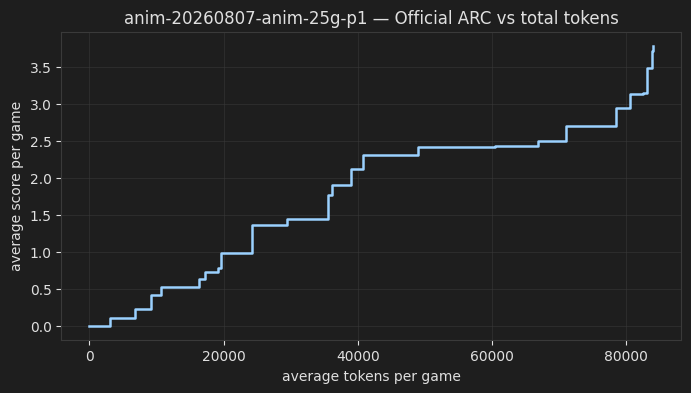
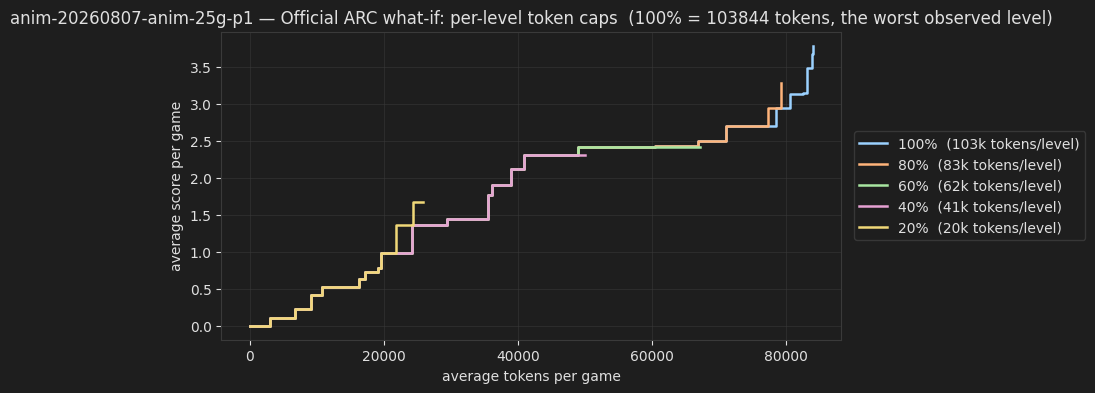
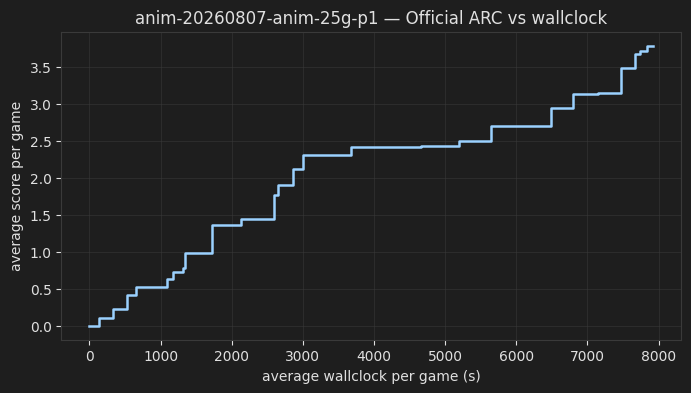
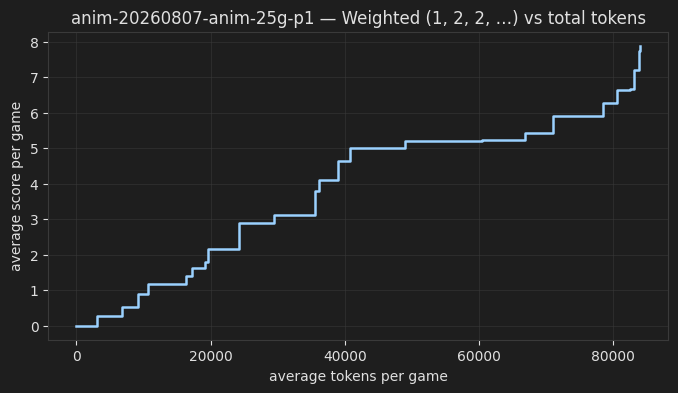
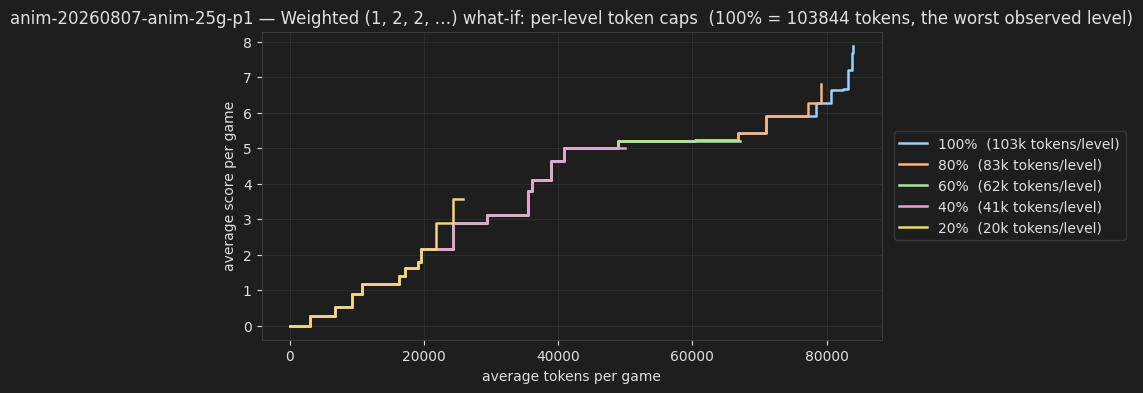
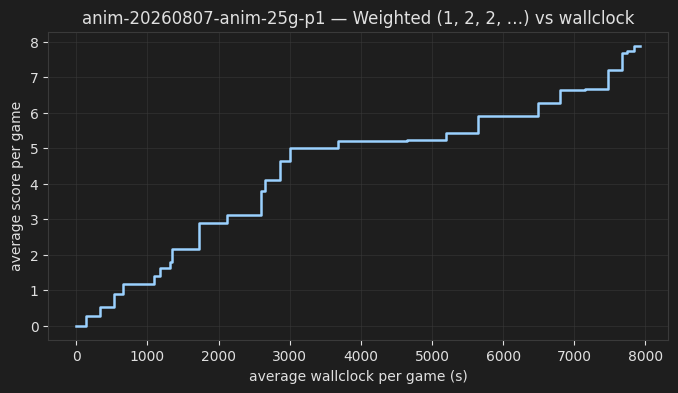
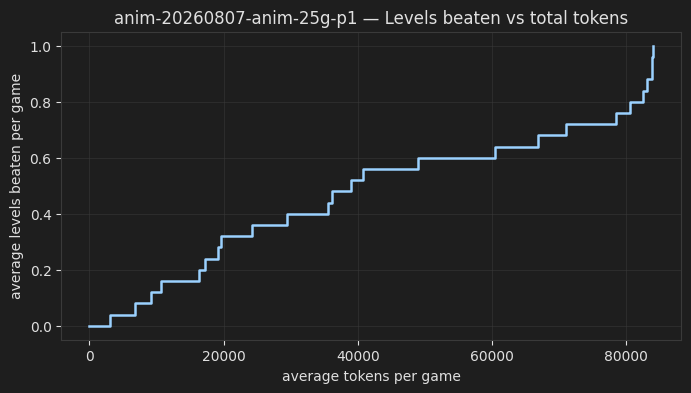
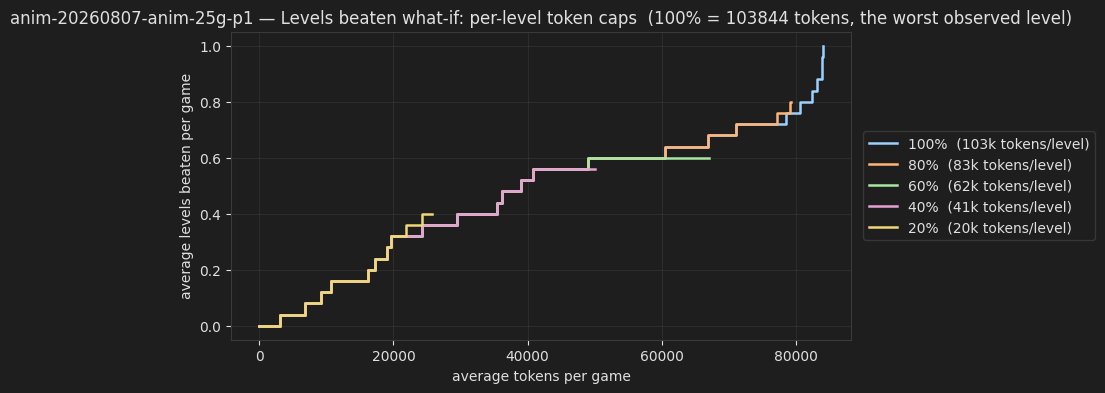
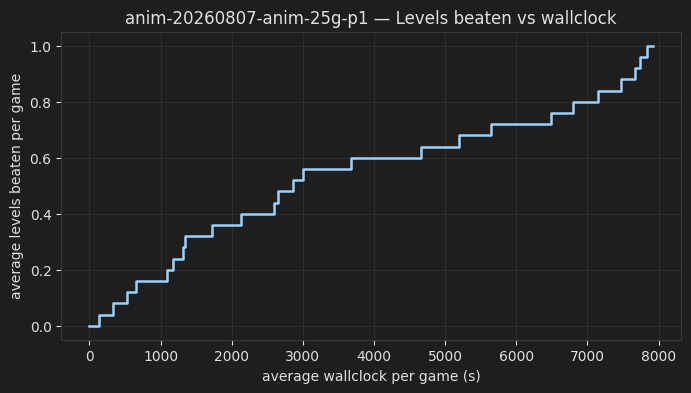
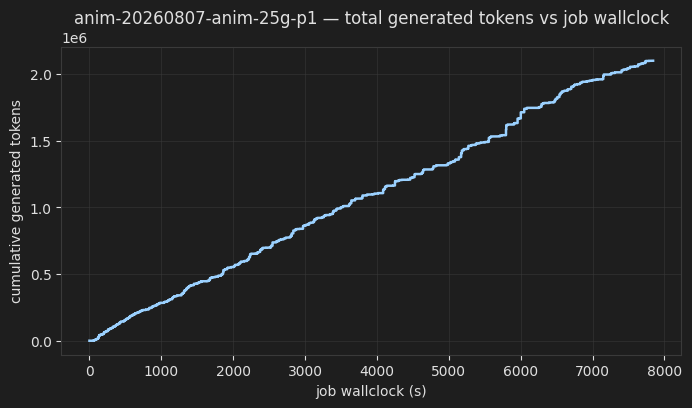
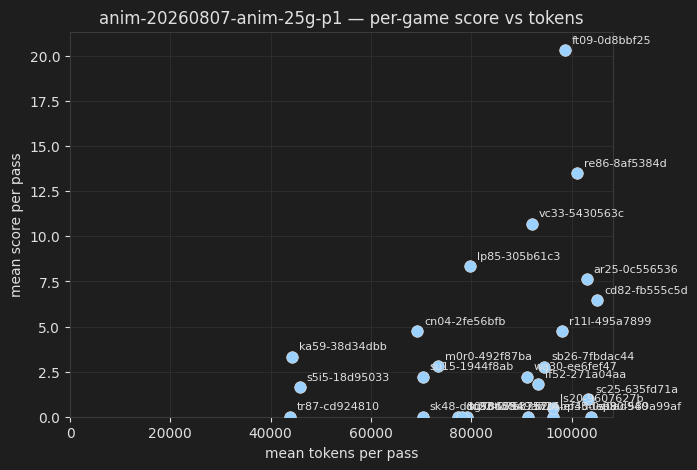
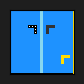
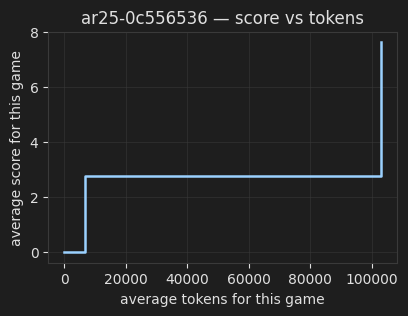
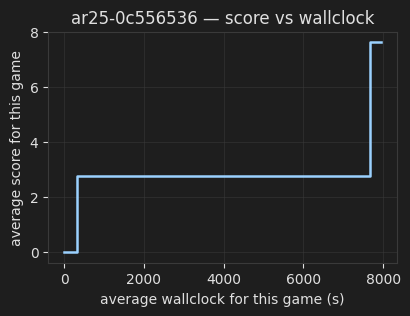
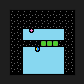
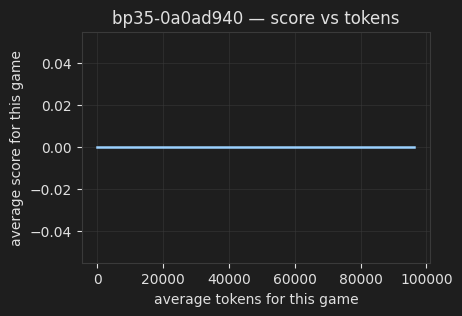
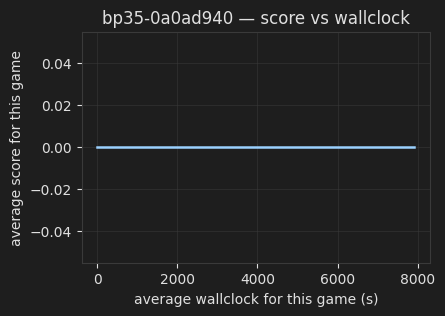
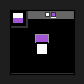
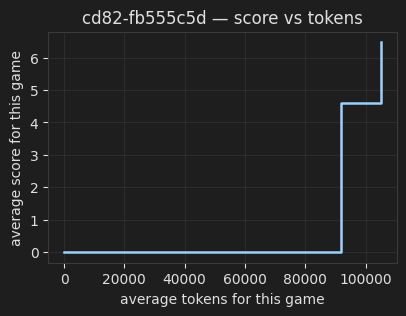
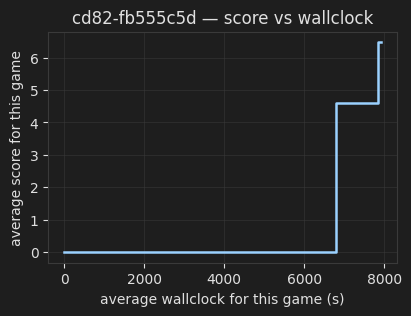
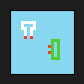
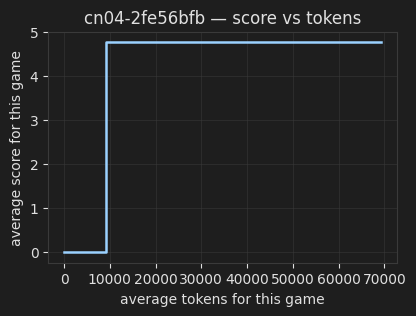
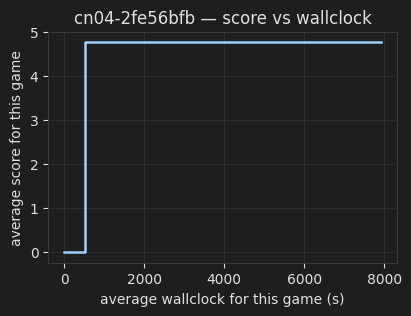
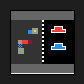
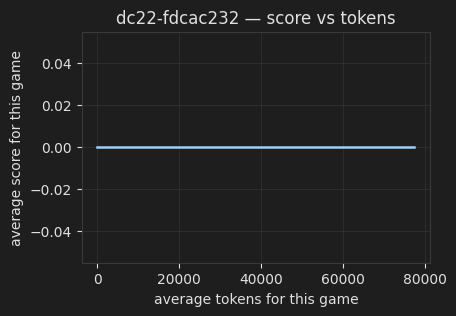
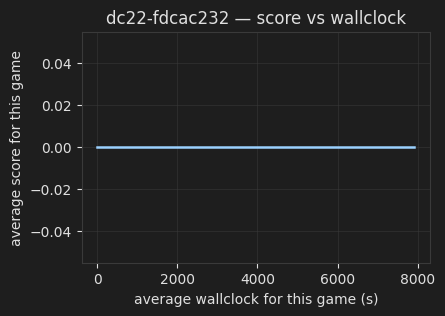
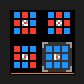
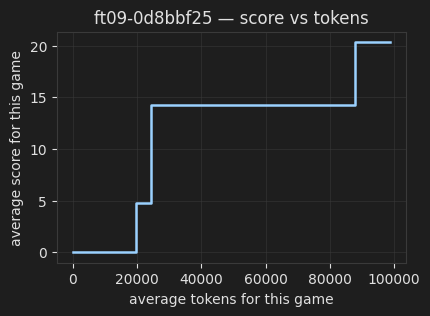
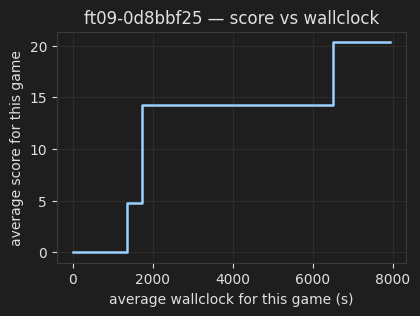
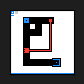
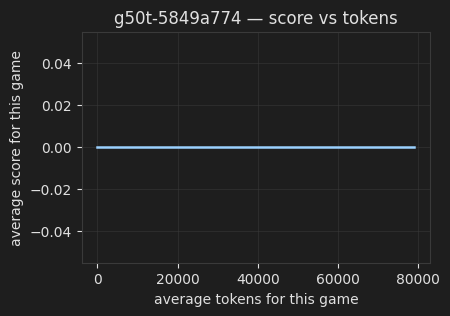
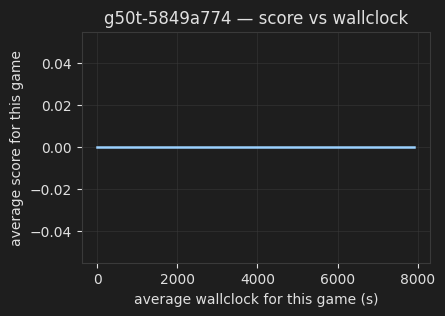
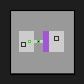
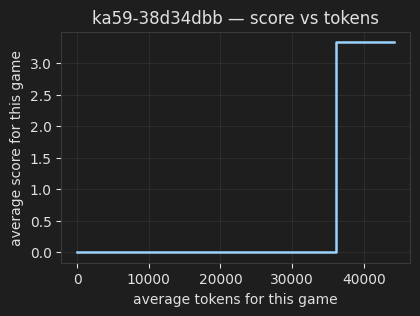
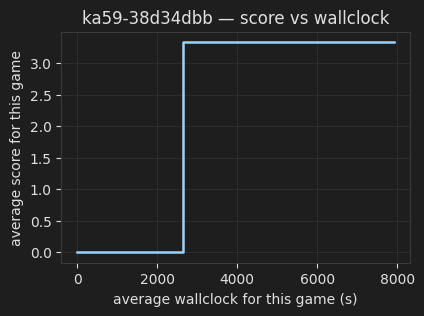
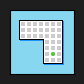
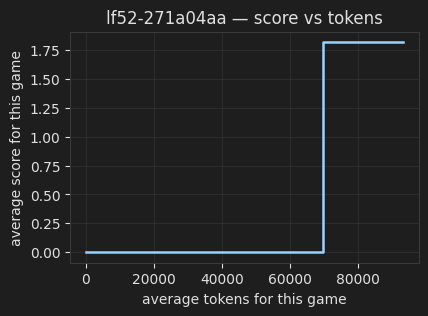
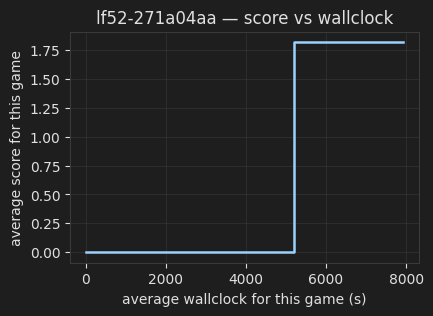
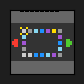
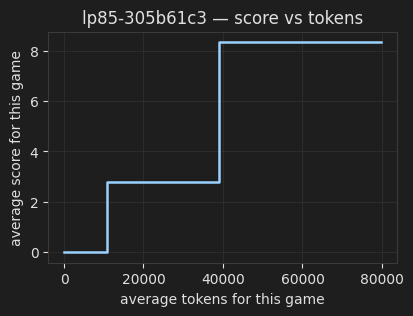
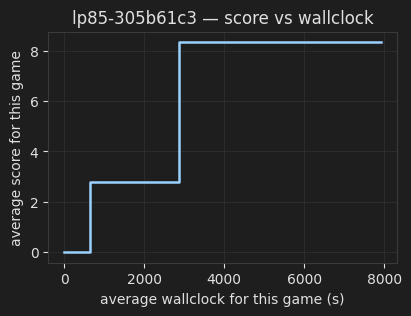
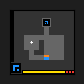
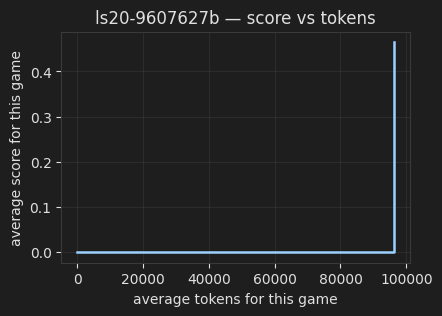
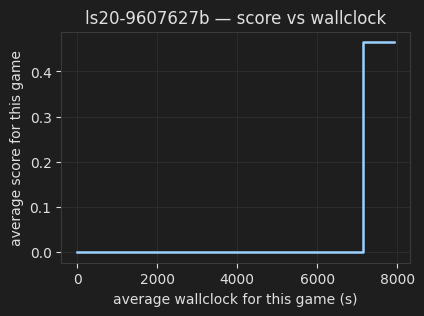
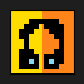
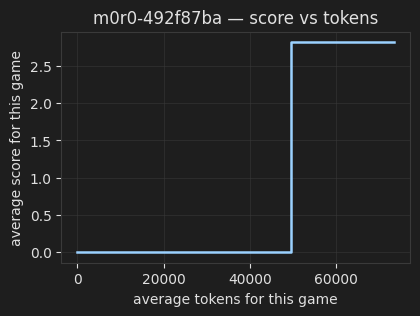
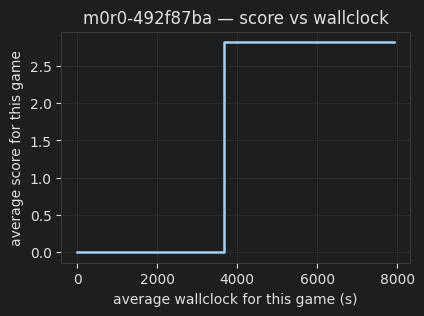
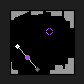
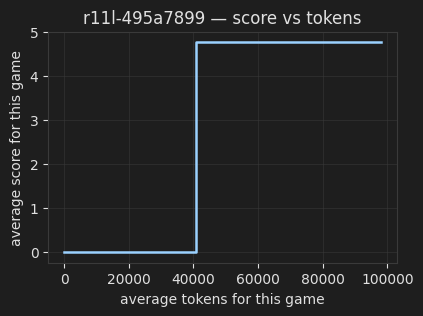
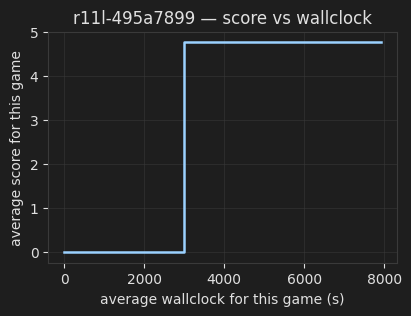
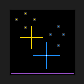
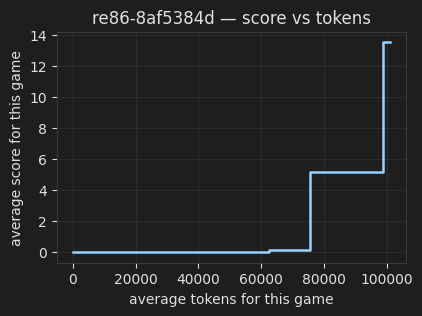
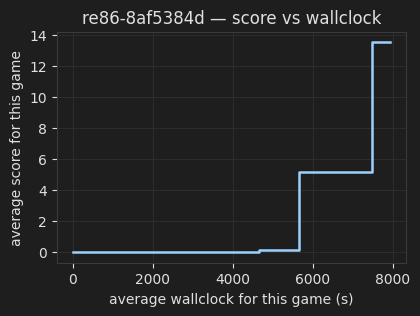
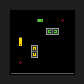
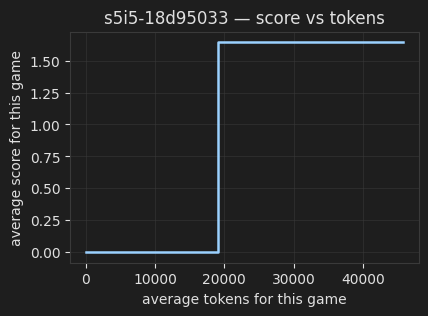
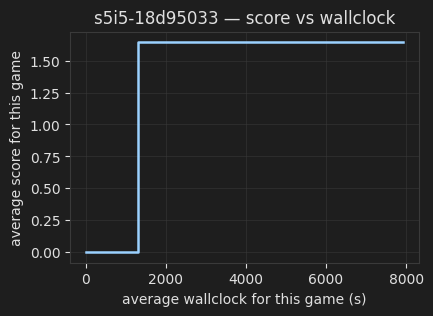
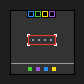
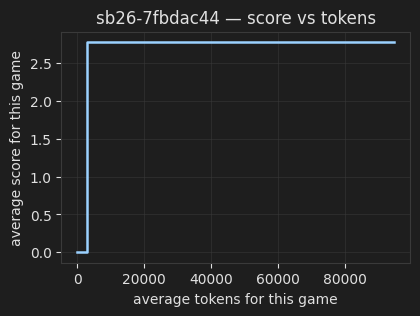
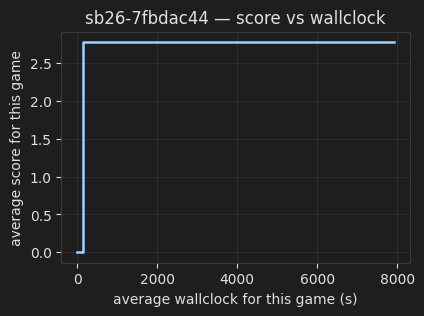
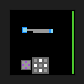
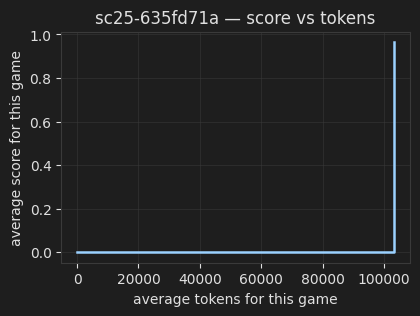
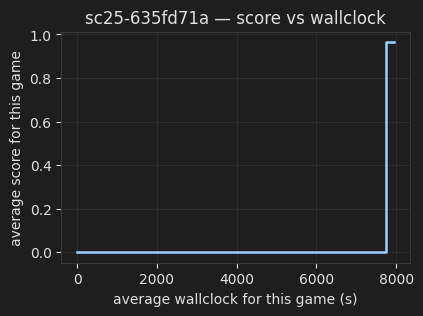
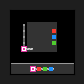
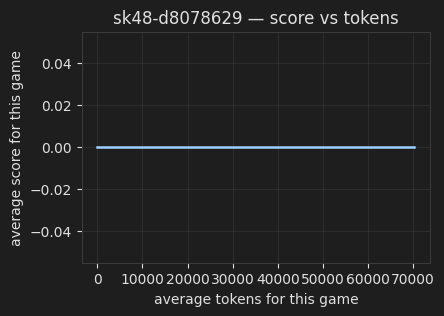
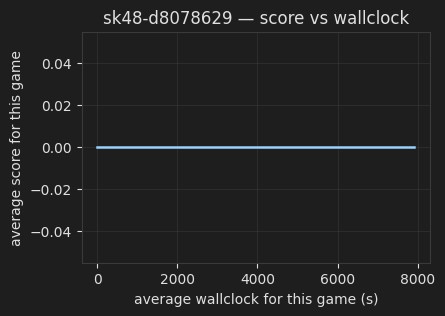
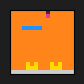
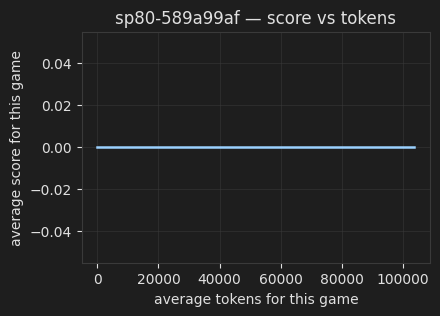
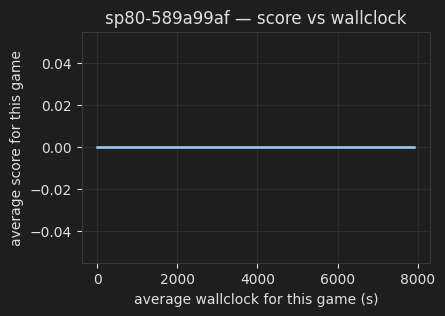
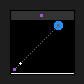
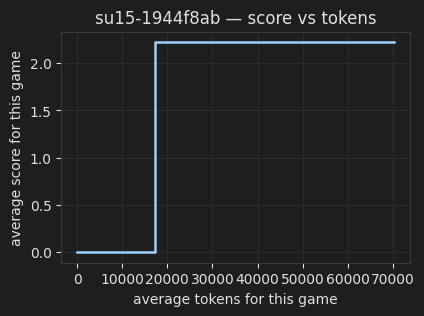
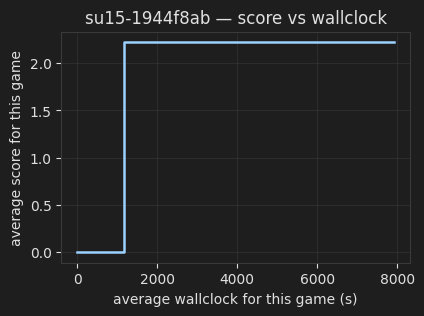
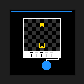
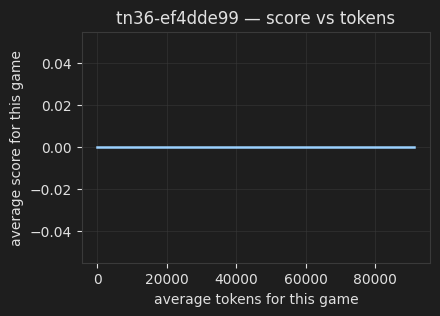
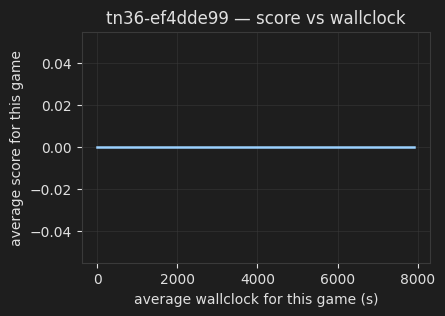
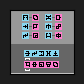
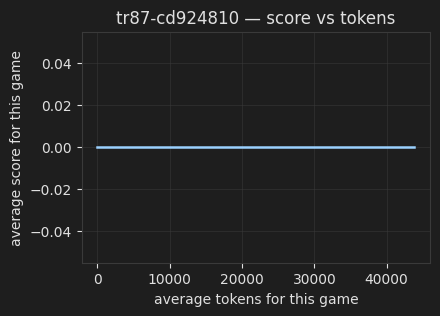
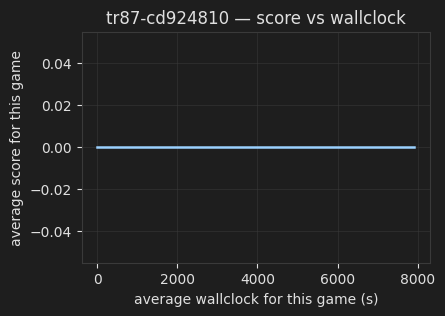
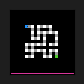
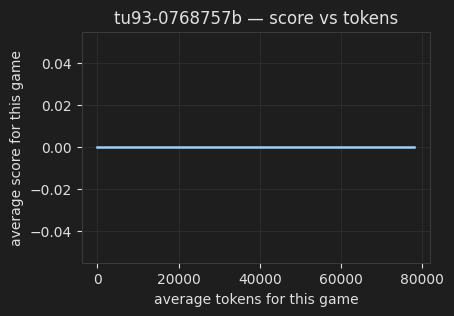
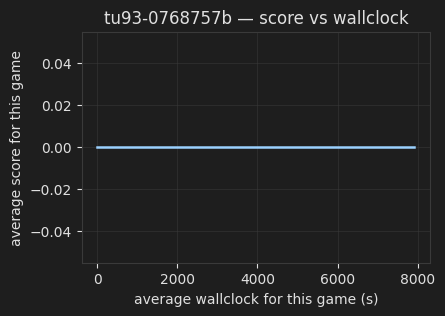
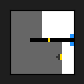
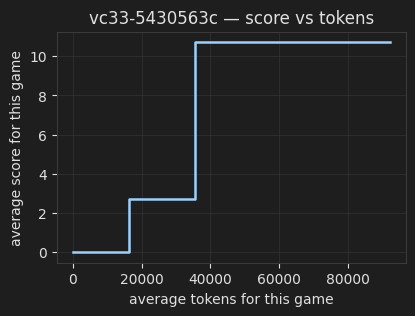
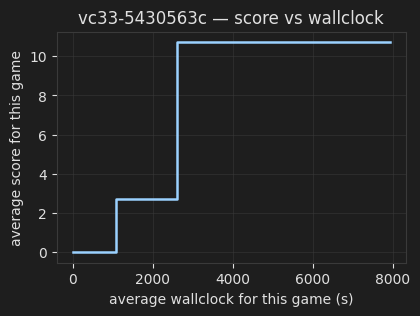
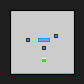
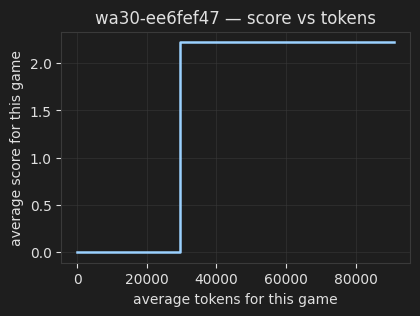
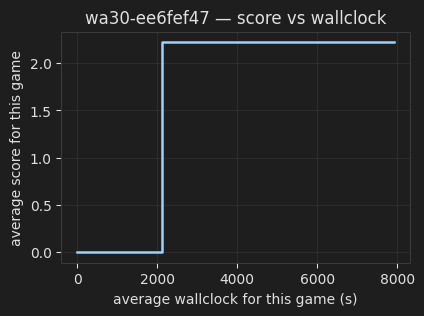
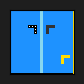
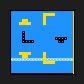
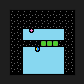
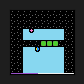
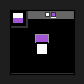
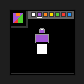
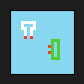
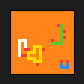
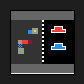
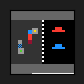
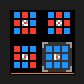
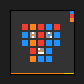
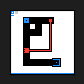
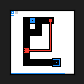
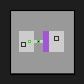
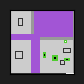
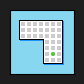
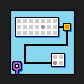
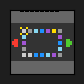
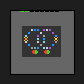
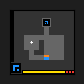
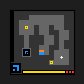
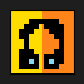
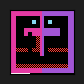
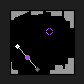
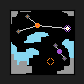
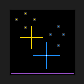
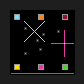
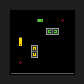
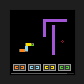
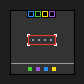
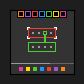
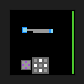
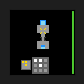
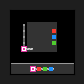
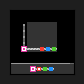
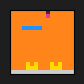
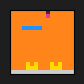
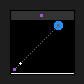
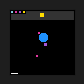
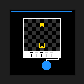
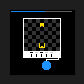
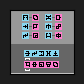
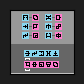
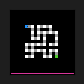
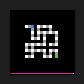
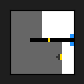
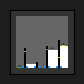
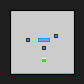
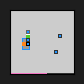

In [10]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")